Use Hough transformation to detection circles in GUV images.

Liya Ding 2025.05.

In [57]:
import sys
import os
from glob import glob
import numpy as np
import matplotlib.pyplot as plt
from tifffile import imread, imwrite
from csbdeep.utils import normalize
from csbdeep.utils import download_and_extract_zip_file
import tifffile
from skimage.transform import resize
import pandas as pd


In [58]:
root_folder = '/mnt/d/lding/CLS/mousumiLiuDinner/raw_data/Microtubule_GUV-Liu-20250106T211105Z-001'

folder_list = [x for x in os.listdir(root_folder) if os.path.isdir(os.path.join(root_folder, x)) ]

In [59]:
output_folder = '/mnt/d/lding/CLS/mousumiLiuDinner/set1to5_processed_results'
processed_folder = output_folder+'/Microtubule_GUV-Liu-20250106T211105Z-001/processed_GUV_MT/'

if not os.path.isdir(output_folder):   os.makedirs(output_folder)
if not os.path.isdir(processed_folder):   os.makedirs(processed_folder)


In [60]:
folder_list

['Microtubule_GUV-Liu', 'processed_MT']

In [61]:
df = pd.DataFrame(columns=['GUV_folder_path','GUV_file_name','MT_folder_path','MT_file_name','condition','date'])

for  folder_ID in range(len(folder_list)):
    sub_folder = os.path.join(root_folder, folder_list[folder_ID])
    # print(sub_folder)
    sub_folder_list = [x for x in os.listdir(sub_folder) if os.path.isdir(os.path.join(sub_folder, x)) ]
    for  sub_folder_ID in range(len(sub_folder_list)):
        sub_sub_folder =  os.path.join(sub_folder, sub_folder_list[sub_folder_ID])
        # print(sub_sub_folder)
        sub_sub_folder_list = [x for x in os.listdir(sub_sub_folder) if os.path.isdir(os.path.join(sub_sub_folder, x)) ]
        for  sub_sub_folder_ID in range(len(sub_sub_folder_list)):
            sub_sub_sub_folder =  os.path.join(sub_sub_folder, sub_sub_folder_list[sub_sub_folder_ID])
            # print(sub_sub_sub_folder)
            GUV_sub_sub_sub_folder =  os.path.join(sub_sub_sub_folder, 'GUV')
            MT_sub_sub_sub_folder =  os.path.join(sub_sub_sub_folder, 'Microtubule')
            
            # print(sub_sub_sub_sub_folder)
            sub_sub_sub_filename_list = [x for x in os.listdir(GUV_sub_sub_sub_folder) if os.path.isfile(os.path.join(GUV_sub_sub_sub_folder, x)) and ('.TIF' in x) ]
            for  sub_sub_sub_filename_ID in range(len(sub_sub_sub_filename_list)):
                GUV_filename =  sub_sub_sub_filename_list[sub_sub_sub_filename_ID]


                if GUV_filename[-7:] == "GUV.TIF":
                    MT_filename = GUV_filename.replace("GUV.TIF","MT.TIF")
                else:
                    MT_filename = GUV_filename.replace("_w1561.TIF","_w2640.TIF")


                GUV_file_path = os.path.join(GUV_sub_sub_sub_folder, GUV_filename)
                MT_file_path = os.path.join(MT_sub_sub_sub_folder, MT_filename)

                if(os.path.isfile(GUV_file_path) and os.path.isfile(MT_file_path)):
                ##########################
                # Liya check if both path exists                
                    # print(file_path)                    
                    s = pd.DataFrame([[GUV_sub_sub_sub_folder, GUV_filename,MT_sub_sub_sub_folder, MT_filename, sub_folder_list[sub_folder_ID],sub_sub_folder_list[sub_sub_folder_ID]]],
                                    columns=['GUV_folder_path','GUV_file_name','MT_folder_path','MT_file_name','condition','date'])
                    df = pd.concat([df, s], ignore_index=True)
                else:
                    MT_filename = GUV_filename.replace("_w2561.TIF","_w1640.TIF")
                    MT_file_path = os.path.join(MT_sub_sub_sub_folder, MT_filename)

                    if(os.path.isfile(GUV_file_path) and os.path.isfile(MT_file_path)):
                        s = pd.DataFrame([[GUV_sub_sub_sub_folder, GUV_filename,MT_sub_sub_sub_folder, MT_filename, sub_folder_list[sub_folder_ID],sub_sub_folder_list[sub_sub_folder_ID]]],
                                    columns=['GUV_folder_path','GUV_file_name','MT_folder_path','MT_file_name','condition','date'])
                        df = pd.concat([df, s], ignore_index=True)
                    else:
                        print(GUV_file_path)
                        print(MT_file_path)


/mnt/d/lding/CLS/mousumiLiuDinner/raw_data/Microtubule_GUV-Liu-20250106T211105Z-001/Microtubule_GUV-Liu/1_10 Tau_Tubulin/Date 3/GUV/Image 4_GUV.TIF
/mnt/d/lding/CLS/mousumiLiuDinner/raw_data/Microtubule_GUV-Liu-20250106T211105Z-001/Microtubule_GUV-Liu/1_10 Tau_Tubulin/Date 3/Microtubule/Image 4_GUV.TIF
/mnt/d/lding/CLS/mousumiLiuDinner/raw_data/Microtubule_GUV-Liu-20250106T211105Z-001/Microtubule_GUV-Liu/1_10 Tau_Tubulin/Date 5/GUV/1 uM tau mt encap guv53_w1561.TIF
/mnt/d/lding/CLS/mousumiLiuDinner/raw_data/Microtubule_GUV-Liu-20250106T211105Z-001/Microtubule_GUV-Liu/1_10 Tau_Tubulin/Date 5/Microtubule/1 uM tau mt encap guv53_w1561.TIF
/mnt/d/lding/CLS/mousumiLiuDinner/raw_data/Microtubule_GUV-Liu-20250106T211105Z-001/Microtubule_GUV-Liu/2_10 Tau_Tubulin/Date 4/GUV/IMAGE 31_w2561.TIF
/mnt/d/lding/CLS/mousumiLiuDinner/raw_data/Microtubule_GUV-Liu-20250106T211105Z-001/Microtubule_GUV-Liu/2_10 Tau_Tubulin/Date 4/Microtubule/IMAGE 31_w1640.TIF


In [62]:
df

,GUV_folder_path,GUV_file_name,MT_folder_path,MT_file_name,condition,date
0,/mnt/d/lding/CLS/mousumiLiuDinner/raw_data/Mic...,Image10_GUV.TIF,/mnt/d/lding/CLS/mousumiLiuDinner/raw_data/Mic...,Image10_MT.TIF,1_10 Tau_Tubulin,Date 1
1,/mnt/d/lding/CLS/mousumiLiuDinner/raw_data/Mic...,Image1_GUV.TIF,/mnt/d/lding/CLS/mousumiLiuDinner/raw_data/Mic...,Image1_MT.TIF,1_10 Tau_Tubulin,Date 1
2,/mnt/d/lding/CLS/mousumiLiuDinner/raw_data/Mic...,Image2_GUV.TIF,/mnt/d/lding/CLS/mousumiLiuDinner/raw_data/Mic...,Image2_MT.TIF,1_10 Tau_Tubulin,Date 1
3,/mnt/d/lding/CLS/mousumiLiuDinner/raw_data/Mic...,Image3_GUV.TIF,/mnt/d/lding/CLS/mousumiLiuDinner/raw_data/Mic...,Image3_MT.TIF,1_10 Tau_Tubulin,Date 1
4,/mnt/d/lding/CLS/mousumiLiuDinner/raw_data/Mic...,Image4_GUV.TIF,/mnt/d/lding/CLS/mousumiLiuDinner/raw_data/Mic...,Image4_MT.TIF,1_10 Tau_Tubulin,Date 1
...,...,...,...,...,...,...
380,/mnt/d/lding/CLS/mousumiLiuDinner/raw_data/Mic...,2 uM tau mt encap guv88_w1561.TIF,/mnt/d/lding/CLS/mousumiLiuDinner/raw_data/Mic...,2 uM tau mt encap guv88_w2640.TIF,3_10 Tau_Tubulin,Date 5
381,/mnt/d/lding/CLS/mousumiLiuDinner/raw_data/Mic...,2 uM tau mt encap guv89_w1561.TIF,/mnt/d/lding/CLS/mousumiLiuDinner/raw_data/Mic...,2 uM tau mt encap guv89_w2640.TIF,3_10 Tau_Tubulin,Date 5
382,/mnt/d/lding/CLS/mousumiLiuDinner/raw_data/Mic...,2 uM tau mt encap guv91_w1561.TIF,/mnt/d/lding/CLS/mousumiLiuDinner/raw_data/Mic...,2 uM tau mt encap guv91_w2640.TIF,3_10 Tau_Tubulin,Date 5
383,/mnt/d/lding/CLS/mousumiLiuDinner/raw_data/Mic...,2 uM tau mt encap guv94_w1561.TIF,/mnt/d/lding/CLS/mousumiLiuDinner/raw_data/Mic...,2 uM tau mt encap guv94_w2640.TIF,3_10 Tau_Tubulin,Date 5


### Segmentation with cellpose pretrained models


In [63]:
from skimage.measure import label, regionprops, regionprops_table
from matplotlib import cm
from skimage import filters

In [64]:
from matplotlib import cm
# build the colormap with iterative tab10
tab10 = cm.get_cmap('tab10', 10)
for i in range(10):
    tab10.colors = np.concatenate([tab10.colors,tab10.colors],axis=0)    
tab10.colors = np.concatenate([np.zeros([1,4]),tab10.colors],axis=0)

newmap = cm.get_cmap('tab10', 200+1)
newmap.colors = tab10.colors[0:200+1,:]
newmap.colors[0,:]  = np.zeros([1,4])
newmap.colors[0,3] = 1

In [65]:
number_img = len(df)
guv_img_all = np.zeros([number_img,512,512])
mt_img_all = np.zeros([number_img,512,512])

for row_ID in range(number_img): 
    GUV_file_path = os.path.join(df.iloc[row_ID]['GUV_folder_path'],df.iloc[row_ID]['GUV_file_name'])
    MT_file_path = os.path.join(df.iloc[row_ID]['MT_folder_path'],df.iloc[row_ID]['MT_file_name'])
           
    # print(file_path)
    guv_img = imread(GUV_file_path)
    mt_img = imread(MT_file_path)
    if guv_img.ndim ==3:
        guv_img = guv_img.max(axis=0).squeeze()
    if mt_img.ndim ==3:
        mt_img = mt_img.max(axis=0).squeeze()

    guv_img_all[row_ID,0:guv_img.shape[0],0:guv_img.shape[1]] = guv_img
    mt_img_all[row_ID,0:mt_img.shape[0],0:mt_img.shape[1]] = mt_img
    

In [66]:
guv_img_all[guv_img_all==0] = np.nan
mt_img_all[mt_img_all==0] = np.nan

In [67]:
guv_bg_img = np.nanmedian(guv_img_all, axis=0)
mt_bg_img = np.nanmedian(mt_img_all, axis=0)


from skimage.filters import median, gaussian
from skimage.morphology import disk

guv_bg_img_filtered = median(guv_bg_img, disk(5))
mt_bg_img_filtered  = median(mt_bg_img, disk(5))

# guv_bg_img_filtered_smooth = gaussian(guv_bg_img_filtered, 5)
# mt_bg_img_filtered_smooth = gaussian(mt_bg_img_filtered, 5)


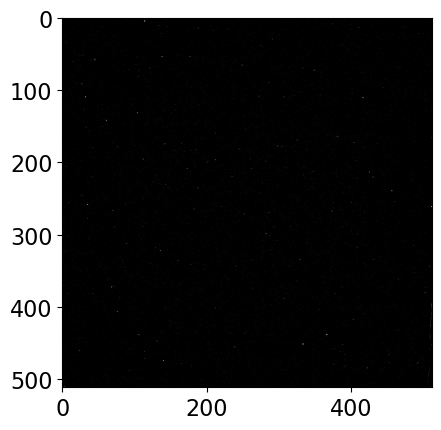

In [68]:
plt.imshow(guv_bg_img - guv_bg_img_filtered, clim=(0,70), cmap='gray')

In [69]:
guv_bg_int = np.nanmedian(guv_bg_img.ravel()) 
mt_bg_int = np.nanmedian(mt_bg_img.ravel()) 

In [70]:
guv_bg_int

156.0

In [71]:
mt_bg_int = 120

In [72]:
guv_bg_int = 110

In [73]:
guv_img_all = np.nan_to_num(guv_img_all, nan=guv_bg_int)
mt_img_all = np.nan_to_num(mt_img_all, nan=mt_bg_int)

In [74]:
pad_guv_img_all = np.zeros([number_img,512+128,512+128]) + guv_bg_int
guv_img_no_bg = np.zeros([number_img,512,512])

pad_mt_img_all = np.zeros([number_img,512+128,512+128]) + mt_bg_int
mt_img_no_bg = np.zeros([number_img,512,512])

for i in range(number_img):

    GUV_file_name = df.iloc[i]['GUV_file_name']
    condition = df.iloc[i]['condition']
    date = df.iloc[i]['date']

    # fig1, ax1 = plt.subplots(2, 4, figsize=(16, 8))
    # fig1.suptitle(condition+', '+date+', '+GUV_file_name)
    # ax1[0,0].imshow(guv_bg_img,cmap='gray',vmin=80,vmax=500)
    # ax1[0,0].axis('off')
    # ax1[0,0].set_title('bg')
    # ax1[0,1].imshow(guv_img_all[i,:,:],cmap='gray',vmin=80,vmax=500)
    # ax1[0,1].axis('off')
    # ax1[0,1].set_title('org')
    # guv_img_no_bg[i,:,:]  = guv_img_all[i,:,:] 
    guv_img_no_bg[i,:,:]  = guv_img_all[i,:,:] - guv_bg_img_filtered + guv_bg_int + 20
    
    # ax1[0,2].imshow(guv_img_no_bg[i,:,:],cmap='gray',vmin=80,vmax=500)
    # ax1[0,2].axis('off')
    # ax1[0,2].set_title('bg rm')
    pad_guv_img_all[i,64:64+512,64:64+512] = guv_img_no_bg[i,:,:]
    pad_guv_img_all[i,:] = pad_guv_img_all[i,:] + 10
    # ax1[0,3].imshow(pad_guv_img_all[i,:,:],cmap='gray',vmin=80,vmax=500)
    # ax1[0,3].axis('off')
    # ax1[0,3].set_title('pd')

    # ax1[1,0].imshow(mt_bg_img,cmap='gray',vmin=80,vmax=500)
    # ax1[1,0].axis('off')
    # ax1[1,0].set_title('bg')
    # ax1[1,1].imshow(mt_img_all[i,:,:],cmap='gray',vmin=80,vmax=500)
    # ax1[1,1].axis('off')
    # ax1[1,1].set_title('org')
    mt_img_no_bg[i,:,:]  = mt_img_all[i,:,:] - mt_bg_img_filtered + mt_bg_int + 20
    # mt_img_no_bg[i,:,:]  = mt_img_all[i,:,:] 
    # ax1[1,2].imshow(mt_img_no_bg[i,:,:],cmap='gray',vmin=80,vmax=500)
    # ax1[1,2].axis('off')
    # ax1[1,2].set_title('bg rm')
    pad_mt_img_all[i,64:64+512,64:64+512] = mt_img_no_bg[i,:,:]
    pad_mt_img_all[i,:] = pad_mt_img_all[i,:] + 10
    # ax1[1,3].imshow(pad_mt_img_all[i,:,:],cmap='gray',vmin=80,vmax=500)
    # ax1[1,3].axis('off')
    # ax1[1,3].set_title('pd')

    # fig1.savefig(processed_folder+'pre-processed-guv-mt-'+ str(i).zfill(2) +'.jpg')
    # plt.close(fig1)


In [75]:
circle_display_folder =  processed_folder + 'GUV-MT_circle_detect_filter_selected_std15_20250613'
obj_crop_panel_folder = processed_folder + 'GUV-MT_circle_panel_selected_std15_20250613'
tiff_folder= processed_folder + 'GUV-MT_circle_tiff_selected_std15_20250613'
png_folder= processed_folder + 'GUV-MT_circle_png_selected_std15_20250613'  
singlecell_annotation_folder = processed_folder + 'singlecell_circle_selected_std15_20250613' 

if not os.path.isdir(circle_display_folder):   os.makedirs(circle_display_folder)
if not os.path.isdir(obj_crop_panel_folder):   os.makedirs(obj_crop_panel_folder)
if not os.path.isdir(tiff_folder):   os.makedirs(tiff_folder)
if not os.path.isdir(png_folder):   os.makedirs(png_folder)
os.makedirs(singlecell_annotation_folder, exist_ok=True)

In [76]:
mt_img_medianfiltered = median(mt_img, disk(3))

In [77]:
sigma = 1
guv_img_all_smooth = guv_img_all.copy()
mt_img_all_smooth = mt_img_all.copy()
for row_ID in range(df.shape[0]): 
    guv_img_all_smooth = filters.gaussian(guv_img_all[row_ID], sigma)
    mt_img_all_smooth = filters.gaussian(mt_img_all[row_ID], sigma)    

guv_1p = np.percentile(guv_img_all_smooth[guv_img_all_smooth>0],0.001)
guv_99p = np.percentile(guv_img_all_smooth[guv_img_all_smooth>0],99.95)
mt_1p = np.percentile(mt_img_all_smooth[mt_img_all_smooth>0],0.001)
mt_99p = np.percentile(mt_img_all_smooth[mt_img_all_smooth>0],99.95)



guv_0001p = np.percentile(guv_img_all_smooth[guv_img_all_smooth>0],0.01)
guv_9995p = np.percentile(guv_img_all_smooth[guv_img_all_smooth>0],99.95)
mt_0001p = np.percentile(mt_img_all_smooth[mt_img_all_smooth>0],0.01)
mt_9995p = np.percentile(mt_img_all_smooth[mt_img_all_smooth>0],99.95)



guv_0005p = np.percentile(guv_img_all_smooth[guv_img_all_smooth>0],0.05)
guv_9990p = np.percentile(guv_img_all_smooth[guv_img_all_smooth>0],99.90)
mt_0005p = np.percentile(mt_img_all_smooth[mt_img_all_smooth>0],0.05)
mt_9990p = np.percentile(mt_img_all_smooth[mt_img_all_smooth>0],99.90)


guv_0010p = np.percentile(guv_img_all_smooth[guv_img_all_smooth>0],0.10)
guv_9980p = np.percentile(guv_img_all_smooth[guv_img_all_smooth>0],99.80)
mt_0010p = np.percentile(mt_img_all_smooth[mt_img_all_smooth>0],0.10)
mt_9980p = np.percentile(mt_img_all_smooth[mt_img_all_smooth>0],99.80)


guv_0050p = np.percentile(guv_img_all_smooth[guv_img_all_smooth>0],0.50)
guv_9950p = np.percentile(guv_img_all_smooth[guv_img_all_smooth>0],99.50)
mt_0050p = np.percentile(mt_img_all_smooth[mt_img_all_smooth>0],0.50)
mt_9950p = np.percentile(mt_img_all_smooth[mt_img_all_smooth>0],99.50)


# guv_01p = np.percentile(guv_img_all_smooth[guv_img_all_smooth>0],1)
# guv_99p = np.percentile(guv_img_all_smooth[guv_img_all_smooth>0],99)
# mt_01p = np.percentile(mt_img_all_smooth[mt_img_all_smooth>0],1)
# mt_99p = np.percentile(mt_img_all_smooth[mt_img_all_smooth>0],99)





In [78]:
[guv_0050p, guv_9950p, mt_0050p, mt_9950p ]


[133.6434693878156, 382.75649207624093, 164.97406232726257, 226.23792445118315]

In [79]:
[guv_0010p, guv_9980p, mt_0010p, mt_9980p]

[118.89063869567839, 519.8606872946634, 142.09785370623453, 275.5306981143821]

In [80]:
[guv_0005p, guv_9990p, mt_0005p, mt_9990p ]

[117.44306891980669, 572.0944131933445, 139.50961101421908, 486.0221487345501]

In [81]:
[guv_0001p, guv_9995p, mt_0001p, mt_9995p]

[112.12571243266254, 603.4239973301137, 136.1585759326191, 643.8135470394245]

In [82]:
import cv2

In [83]:
from scipy.spatial.distance import cdist

In [84]:
df.iloc[31:40]

,GUV_folder_path,GUV_file_name,MT_folder_path,MT_file_name,condition,date
31,/mnt/d/lding/CLS/mousumiLiuDinner/raw_data/Mic...,1 uM tau + mt encap GUV18_w1561.TIF,/mnt/d/lding/CLS/mousumiLiuDinner/raw_data/Mic...,1 uM tau + mt encap GUV18_w2640.TIF,1_10 Tau_Tubulin,Date 4
32,/mnt/d/lding/CLS/mousumiLiuDinner/raw_data/Mic...,1 uM tau + mt encap GUV19_w1561.TIF,/mnt/d/lding/CLS/mousumiLiuDinner/raw_data/Mic...,1 uM tau + mt encap GUV19_w2640.TIF,1_10 Tau_Tubulin,Date 4
33,/mnt/d/lding/CLS/mousumiLiuDinner/raw_data/Mic...,1 uM tau + mt encap GUV1_w1561.TIF,/mnt/d/lding/CLS/mousumiLiuDinner/raw_data/Mic...,1 uM tau + mt encap GUV1_w2640.TIF,1_10 Tau_Tubulin,Date 4
34,/mnt/d/lding/CLS/mousumiLiuDinner/raw_data/Mic...,1 uM tau + mt encap GUV20_w1561.TIF,/mnt/d/lding/CLS/mousumiLiuDinner/raw_data/Mic...,1 uM tau + mt encap GUV20_w2640.TIF,1_10 Tau_Tubulin,Date 4
35,/mnt/d/lding/CLS/mousumiLiuDinner/raw_data/Mic...,1 uM tau + mt encap GUV21_w1561.TIF,/mnt/d/lding/CLS/mousumiLiuDinner/raw_data/Mic...,1 uM tau + mt encap GUV21_w2640.TIF,1_10 Tau_Tubulin,Date 4
36,/mnt/d/lding/CLS/mousumiLiuDinner/raw_data/Mic...,1 uM tau + mt encap GUV22_w1561.TIF,/mnt/d/lding/CLS/mousumiLiuDinner/raw_data/Mic...,1 uM tau + mt encap GUV22_w2640.TIF,1_10 Tau_Tubulin,Date 4
37,/mnt/d/lding/CLS/mousumiLiuDinner/raw_data/Mic...,1 uM tau + mt encap GUV23_w1561.TIF,/mnt/d/lding/CLS/mousumiLiuDinner/raw_data/Mic...,1 uM tau + mt encap GUV23_w2640.TIF,1_10 Tau_Tubulin,Date 4
38,/mnt/d/lding/CLS/mousumiLiuDinner/raw_data/Mic...,1 uM tau + mt encap GUV24_w1561.TIF,/mnt/d/lding/CLS/mousumiLiuDinner/raw_data/Mic...,1 uM tau + mt encap GUV24_w2640.TIF,1_10 Tau_Tubulin,Date 4
39,/mnt/d/lding/CLS/mousumiLiuDinner/raw_data/Mic...,1 uM tau + mt encap GUV29_w1561.TIF,/mnt/d/lding/CLS/mousumiLiuDinner/raw_data/Mic...,1 uM tau + mt encap GUV29_w2640.TIF,1_10 Tau_Tubulin,Date 4


(2453,)
10.753975912839206
(317,)
1.355901870444787
(10557,)
200.45562258010517
(5025,)
27.581872344488737
(4293,)
113.58562545989057
(6921,)
44.921929231787935
(2821,)
14.13007455870351
(20593,)
21.79971803641325


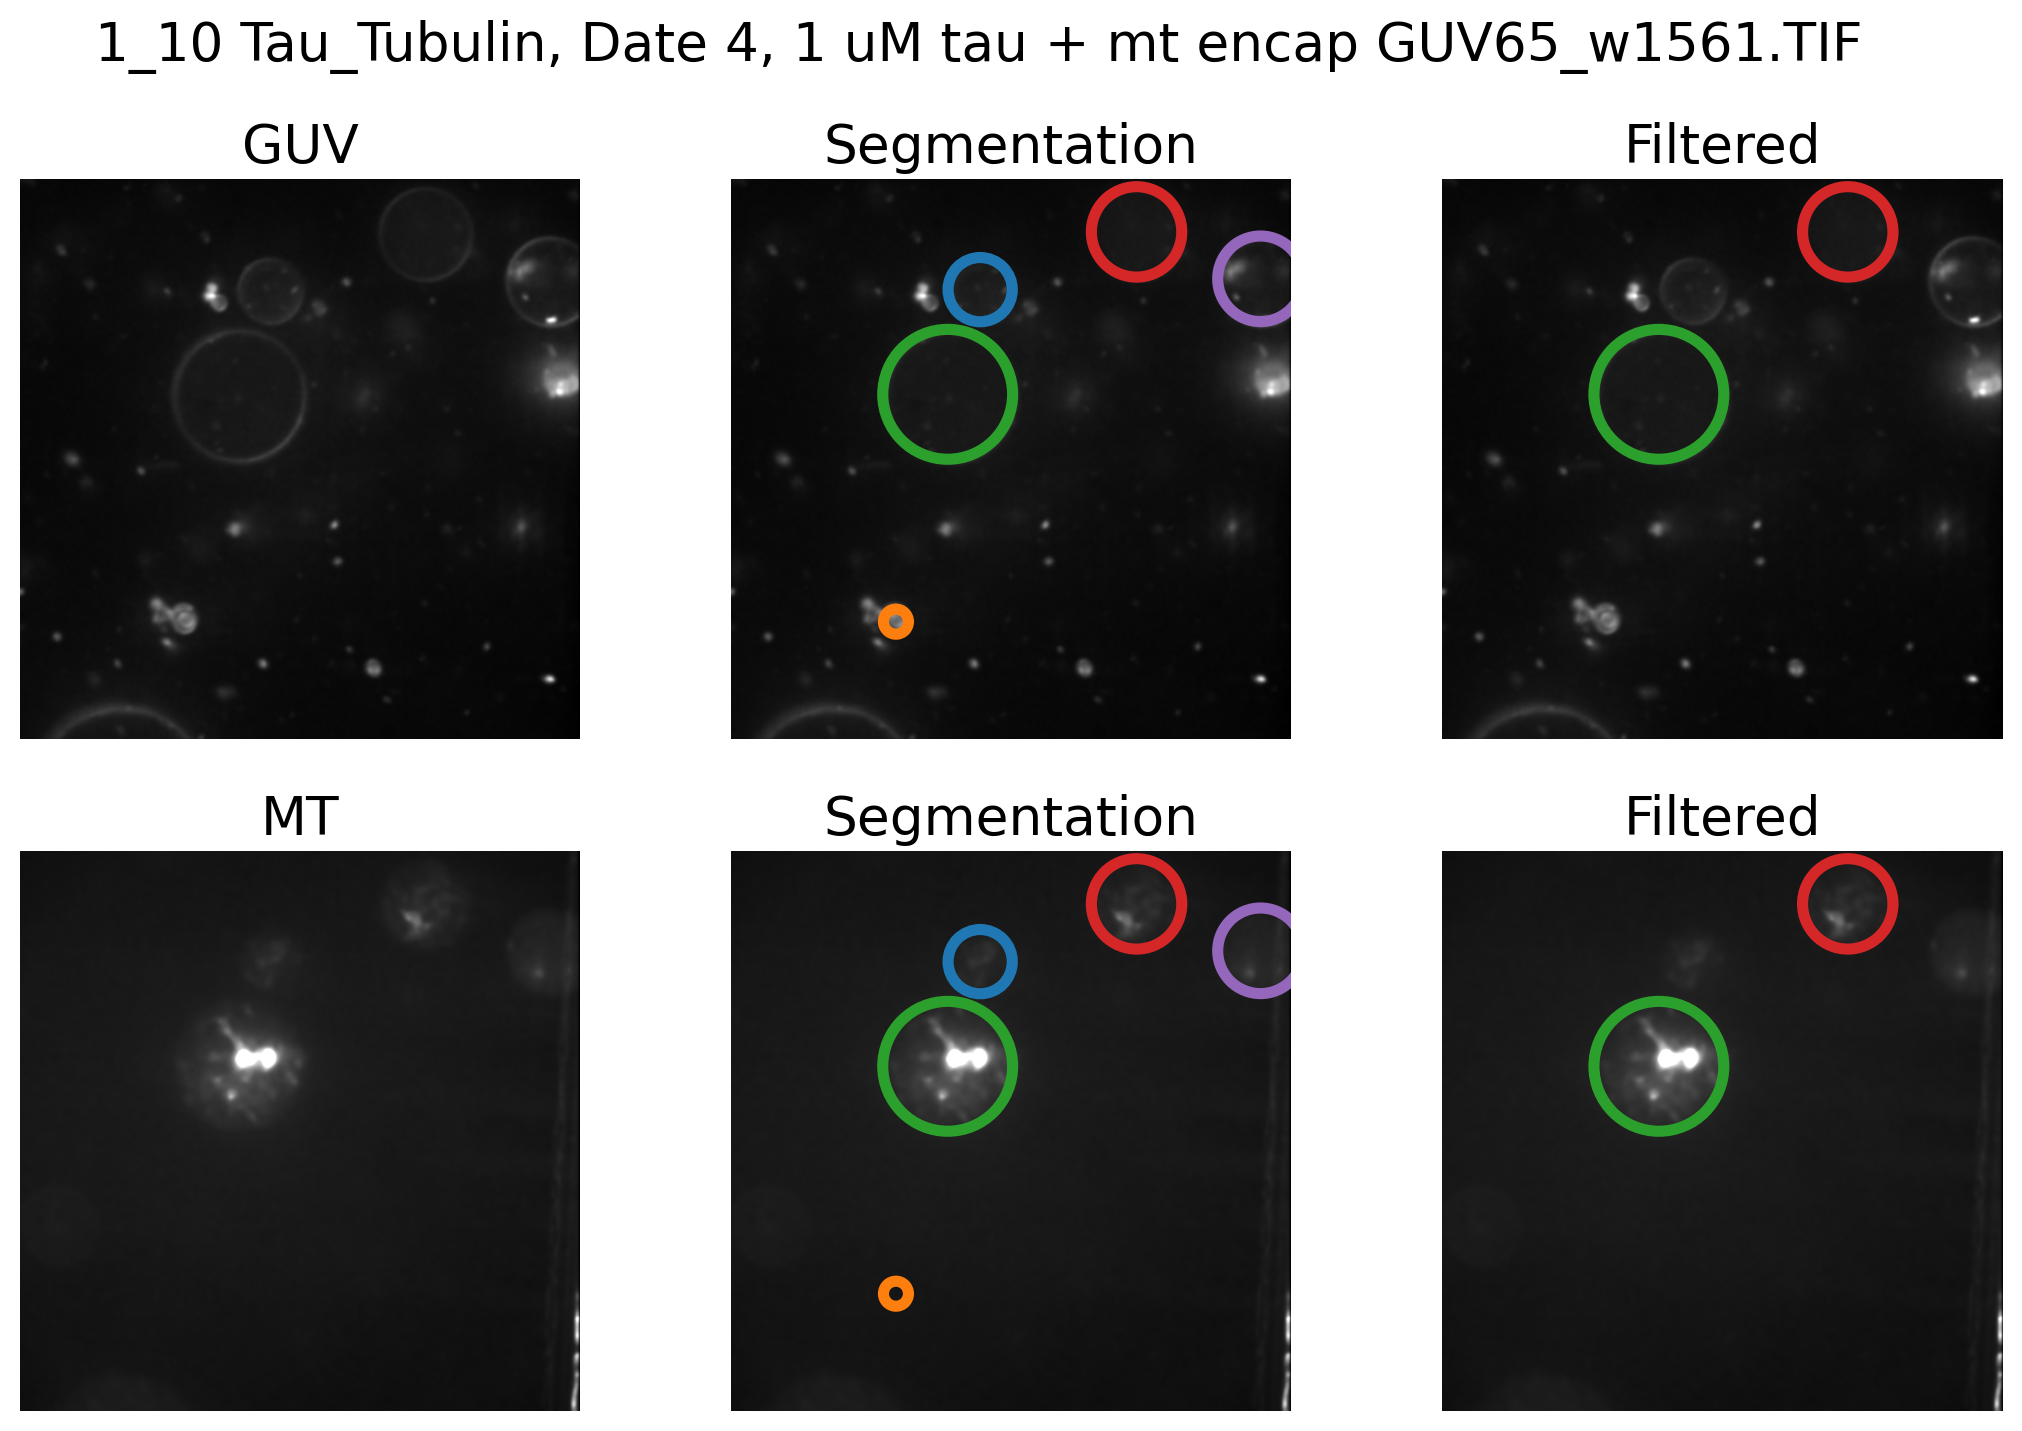

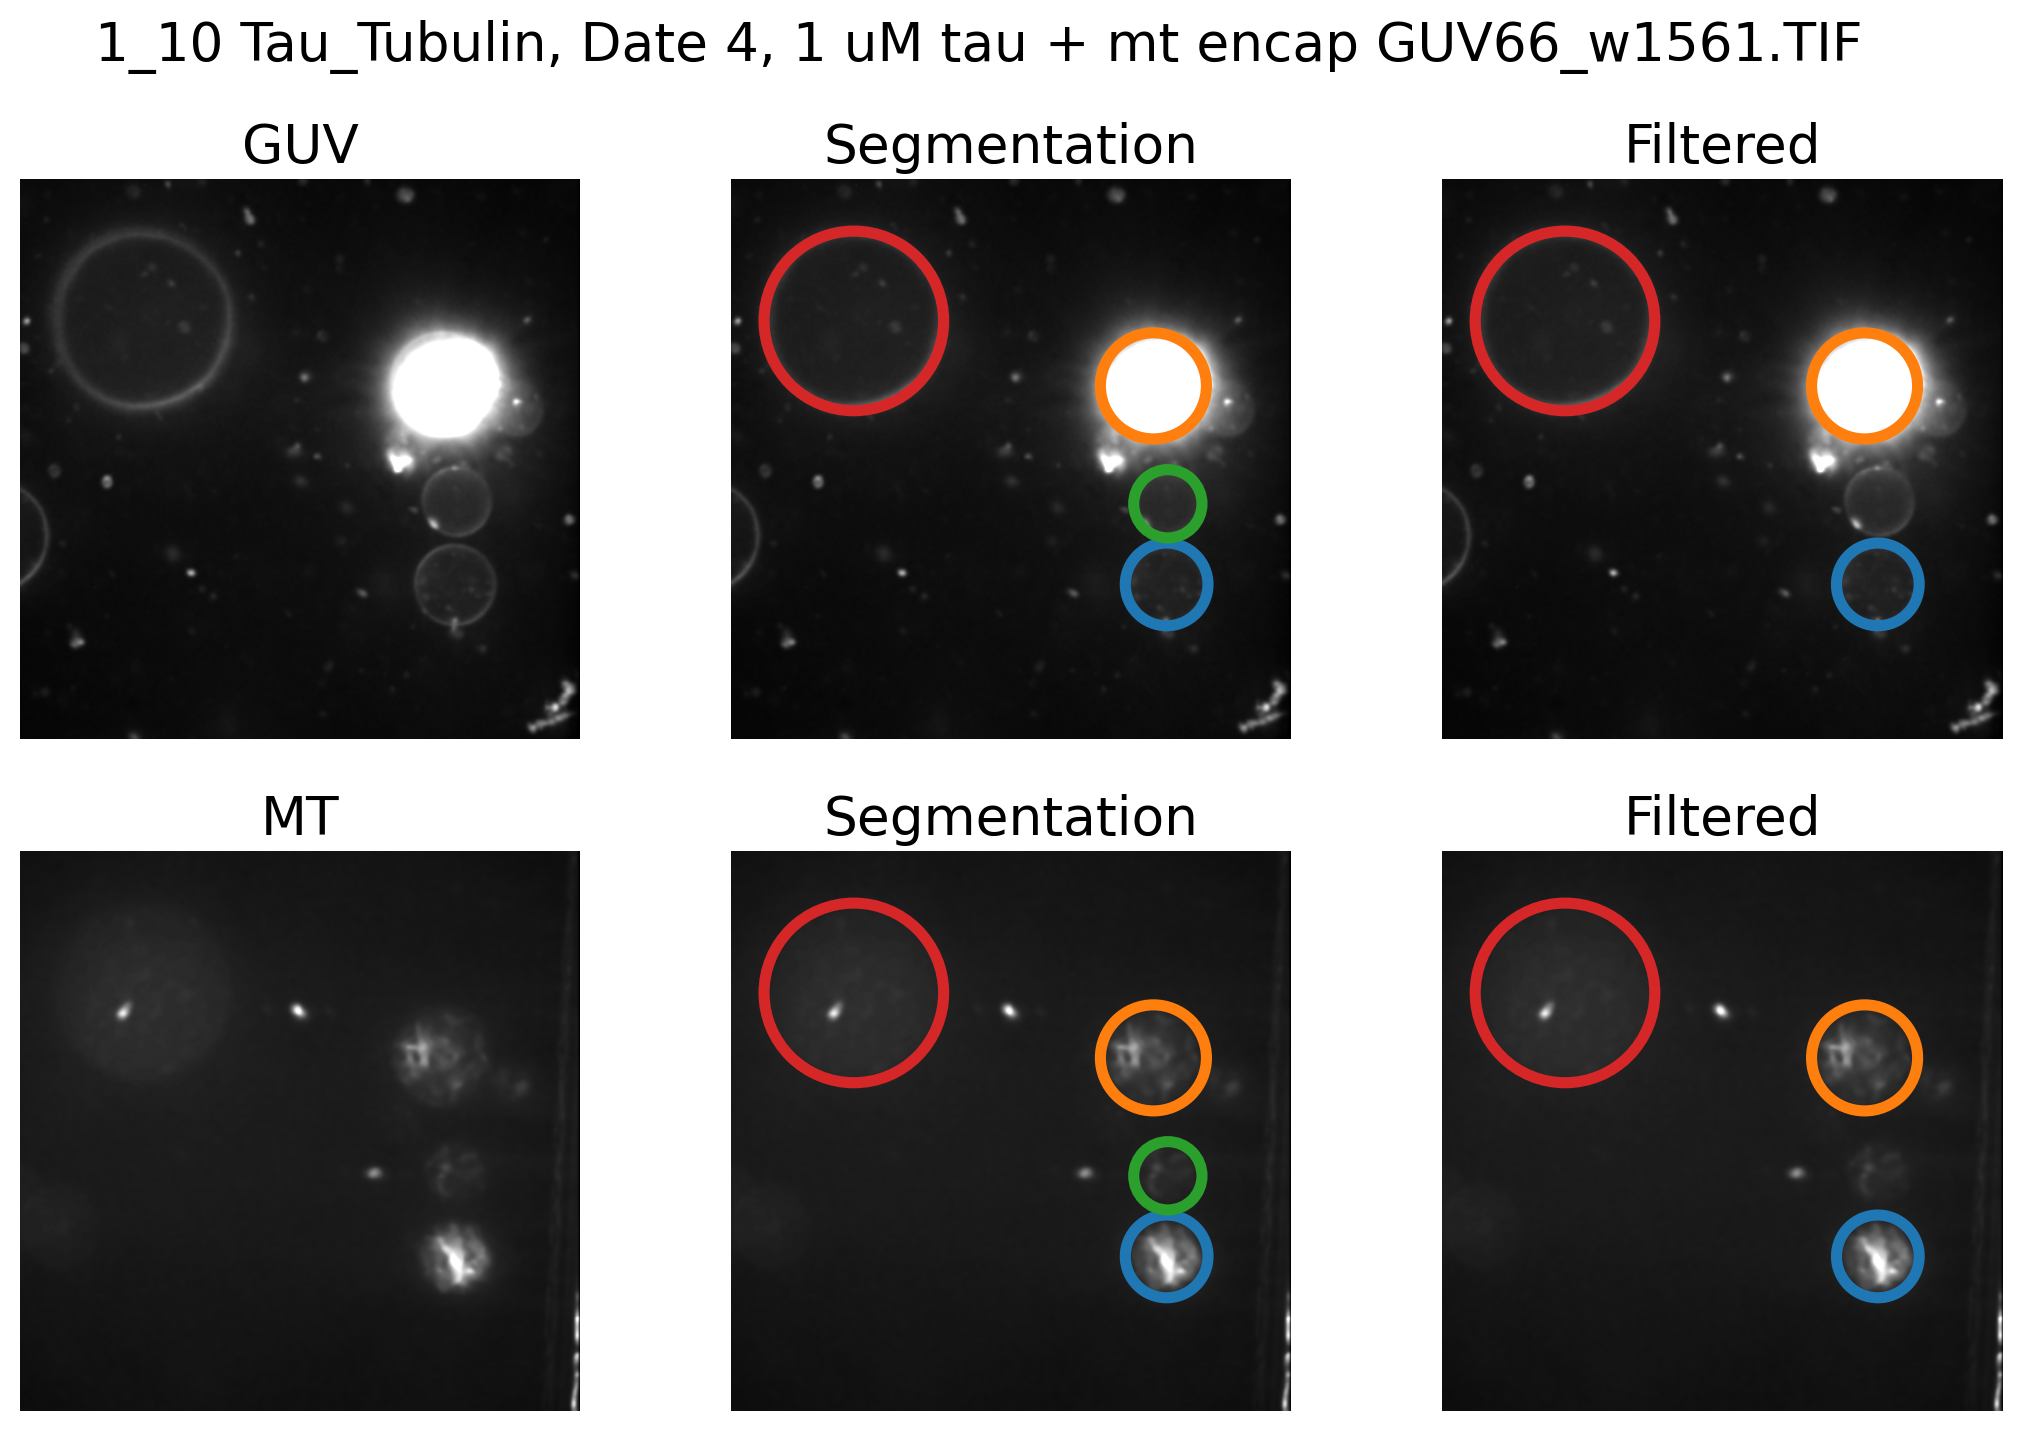

In [86]:
# cell_cropped_array =np.zeros([2000,96,96])
# cell_cropped_cellalone_array =np.zeros([2000,96,96])
# cell_ind=0
plt.rcParams.update({'font.size': 16})
sigma = 1

# cell_index = 0
    
cell_df = pd.DataFrame(columns=['GUV_folder_path','GUV_file_name','MT_folder_path','MT_file_name','condition','date','cell_index','cx','cy','rarius'])

# for row_ID in range(df.shape[0]-2,df.shape[0]-1): 
for row_ID in [69,70]: 
# for row_ID in range(33,34): 
    # print(df.iloc[row_ID]['GUV_file_name'])
    GUV_file_path = os.path.join(df.iloc[row_ID]['GUV_folder_path'],df.iloc[row_ID]['GUV_file_name'])
    MT_file_path = os.path.join(df.iloc[row_ID]['MT_folder_path'],df.iloc[row_ID]['MT_file_name'])
    
    GUV_folder_path = df.iloc[row_ID]['GUV_folder_path']
    MT_folder_path = df.iloc[row_ID]['MT_folder_path']
    GUV_file_name = df.iloc[row_ID]['GUV_file_name']
    MT_file_name = df.iloc[row_ID]['MT_file_name']
    condition = df.iloc[row_ID]['condition']
    date = df.iloc[row_ID]['date']
    # for this image, index the detected cells
    this_image_cell_index = 0
    
    guv_img = guv_img_all[row_ID,:,:]
    mt_img = mt_img_all[row_ID,:,:]
    mt_img_medianfiltered = median(mt_img, disk(3))
    # img = imread(file_path)
    # img = np.sqrt(img)
    guv_smooth = filters.gaussian(guv_img, sigma)
    guv_img_normed = normalize(guv_smooth,1,99)
    mt_smooth = filters.gaussian(mt_img_medianfiltered, sigma)
    guv_img_normed = (guv_smooth-guv_1p)/(guv_99p-guv_1p)
    guv_img_normed[guv_img_normed<0] = 0
    guv_img_normed[guv_img_normed>1] = 1
    mt_img_normed = (mt_smooth-mt_1p)/(mt_99p-mt_1p)
    mt_img_normed[mt_img_normed<0] = 0
    mt_img_normed[mt_img_normed>1] = 1
    
    guv_mt_img = np.zeros([2,512,512])
    guv_mt_img[0,:] = guv_img_normed
    guv_mt_img[1,:] = mt_img_normed
    
    guv_img_pad = pad_guv_img_all[row_ID,:,:]
    mt_img_pad = pad_mt_img_all[row_ID,:,:]
    mt_img_pad = median(mt_img_pad, disk(3))
    

    guv_img_normed_cv2 = cv2.normalize(guv_img_normed, None, 0, 255, cv2.NORM_MINMAX)
    guv_img_normed_cv2 = cv2.GaussianBlur(guv_img_normed_cv2,(5, 5), sigmaX=1)
    guv_img_normed_cv2 = np.uint8(guv_img_normed_cv2)


    # circles = cv2.HoughCircles(
    #      guv_img_normed_cv2, cv2.HOUGH_GRADIENT, dp=1.2, minDist=50, param1=25, param2=40, minRadius=11, maxRadius=80)
    
    # Detect wells using Hough Circle Transform
    small_circles = cv2.HoughCircles(
        guv_img_normed_cv2, cv2.HOUGH_GRADIENT, dp=1.1, minDist=20, param1=30, param2=30, minRadius=10, maxRadius=30
    )
    
    median_circles = cv2.HoughCircles(
        guv_img_normed_cv2, cv2.HOUGH_GRADIENT, dp=1.1, minDist=40, param1=25, param2=40, minRadius=30, maxRadius=60
    )

    large_circles = cv2.HoughCircles(
        guv_img_normed_cv2, cv2.HOUGH_GRADIENT, dp=1.1, minDist=60, param1=20, param2=60, minRadius=60, maxRadius=90
    )

    circle_groups = [small_circles, median_circles,large_circles]

    # Filter out None and extract the [0, :] slice from each valid group
    valid_groups = [c[0, :] for c in circle_groups if c is not None]

    # Concatenate only non-empty results
    if valid_groups:
        circles = np.concatenate(valid_groups, axis=0)
    else:
        circles = np.empty((0, 3))  # Or handle case where no circles are found

    if circles is not None:
        circles_array = np.uint16(np.around(circles))
        detected_centers = np.array([[c[0], c[1]] for c in circles_array])
        detected_radii = np.array([c[2] for c in circles_array])
        mean_radius = np.mean(detected_radii)
    
    fig2, ax2 = plt.subplots(2, 3, figsize=(13, 8),dpi=200)
    # plt.tight_layout()
    fig2.suptitle(condition+', '+date+', '+GUV_file_name)
    ax2[0,0].imshow(guv_img_normed, clim=(0,1), cmap='gray')    
    ax2[0,0].axis('off')
    ax2[0,0].set_title('GUV')
    ax2[0,1].imshow(guv_img_normed, clim=(0,1), cmap='gray')    
    ax2[0,1].axis('off')
    ax2[0,1].set_title('Segmentation')
    
    ax2[1,0].imshow(mt_img_normed, clim=(0,1), cmap='gray')  
    ax2[1,0].axis('off')
    ax2[1,0].set_title('MT')
    
    ax2[1,1].imshow(mt_img_normed, clim=(0,1), cmap='gray')    
    ax2[1,1].axis('off')
    ax2[1,1].set_title('Segmentation')

    ax2[0,2].imshow(guv_img_normed, clim=(0,1), cmap='gray')
    ax2[0,2].axis('off')
    ax2[0,2].set_title('Filtered')

    ax2[1,2].imshow(mt_img_normed, clim=(0,1), cmap='gray')
    ax2[1,2].axis('off')
    ax2[1,2].set_title('Filtered')


    if (detected_centers.shape[0]>0):
        bad_region_flag = np.zeros(circles_array.shape[0])

        for idx, (x, y, r) in enumerate(circles_array, start=1):  # start from circle 1
            
            labels = np.zeros(guv_img_normed_cv2.shape, dtype=np.uint8)  # only for this circle
            cv2.circle(labels, (x, y), r-1, idx, thickness=-1)    
            
            # remove these bad ones:
            # 1 go outside 
            # 2 too big or too small
            # 3 very dim in MT channel
            # 4 low std in MT channel        
            if(x-r<0 or y-r<0 or x+r>guv_img_normed_cv2.shape[0] or y+r>guv_img_normed_cv2.shape[1]):
                bad_region_flag[idx-1]=1  
            else:
                if(r<10 or r>120):
                    bad_region_flag[idx-1]=2   
                else:
                    img_content = mt_img_medianfiltered[labels>0]
                    
                    img_content = img_content[img_content>mt_bg_int]
                    if(img_content.shape[0] == 0):
                        bad_region_flag[idx-1] = 3
                    else:
                        print(img_content.shape)
                        print(img_content.std())
                        if(img_content.std()<15 and img_content.shape[0]<=3000):
                            bad_region_flag[idx-1] = 4
                        if(img_content.std()<10 and img_content.shape[0]<=5000 and img_content.shape[0]>3000):
                            bad_region_flag[idx-1] = 4
                        if(img_content.std()<5 and img_content.shape[0]>5000):
                            bad_region_flag[idx-1] = 4
                            
        
        circle_redetect_con = circles.copy()

        # Assume detected_centers is an (N, 2) array of (x, y)
        dists = cdist(detected_centers, detected_centers) 

        find_pairs = np.zeros_like(dists)
        overlap_circle_idx = 0
        pairs = []
        for i in range(detected_centers.shape[0]-1):
            for j in range(i+1,detected_centers.shape[0]):
                if dists[i,j] <15:
                    # print([i,j])
                    if detected_radii[i]>23 and detected_radii[i]<37 and detected_radii[j]>23 and detected_radii[j]<37:
                        overlap_circle_idx = overlap_circle_idx + 1
                        bad_region_flag[i] = 5
                        bad_region_flag[j] = 5
                        pairs.append([i, detected_centers[i,:],detected_radii[i], j,detected_centers[j,:],detected_radii[j]])

                    if detected_radii[i]>53 and detected_radii[i]<67 and detected_radii[j]>53 and detected_radii[j]<67:
                        overlap_circle_idx = overlap_circle_idx + 1
                        bad_region_flag[i] = 6
                        bad_region_flag[j] = 6
                        pairs.append([i, detected_centers[i,:],detected_radii[i], j,detected_centers[j,:],detected_radii[j]])
                            
        all_dup_circle_redetect = []
        for k in range(overlap_circle_idx):
            i = pairs[k][0]
            circle_1_c = pairs[k][1]
            circle_1_r = pairs[k][2]
            j = pairs[k][3]
            circle_2_c = pairs[k][4]
            circle_2_r = pairs[k][5]

            crop_x_l = max(0, min(circle_1_c[0] - circle_1_r,circle_2_c[0] - circle_2_r) -10)
            crop_x_r = min(guv_img_normed_cv2.shape[0]-1, max(circle_1_c[0] + circle_1_r,circle_2_c[0] + circle_2_r) + 10)
            crop_y_l = max(0, min(circle_1_c[1] - circle_1_r,circle_2_c[1] - circle_2_r) -10)
            crop_y_r = min(guv_img_normed_cv2.shape[1]-1, max(circle_1_c[1] + circle_1_r,circle_2_c[1] + circle_2_r) + 10)
            
            crop_image = guv_img_normed_cv2[crop_y_l:crop_y_r, crop_x_l:crop_x_r ]
            if(bad_region_flag[i] ==5):
                dup_circles = cv2.HoughCircles(crop_image, cv2.HOUGH_GRADIENT, dp=1.1, minDist=20, param1=25, param2=30, minRadius=25, maxRadius=35)         
            if(bad_region_flag[i] ==6):
                dup_circles = cv2.HoughCircles(crop_image, cv2.HOUGH_GRADIENT, dp=1.1, minDist=40, param1=20, param2=40, minRadius=55, maxRadius=65)         
            
            if dup_circles is None:
                if(circle_1_r>circle_2_r):
                    best_circle = [[circle_1_c[0],circle_1_c[1],circle_1_r]]
                    print('pick first')
                    print(best_circle)
                else:
                    best_circle = [[circle_2_c[0],circle_2_c[1],circle_2_r]]
                    print('pick second')
                    print(best_circle)
            else:                    
                best_circle = np.around(dup_circles[0, 0:1]).astype(np.float32)  # shape (1, 3)                
                best_circle[0][0] = best_circle[0][0] + crop_x_l
                best_circle[0][1] = best_circle[0][1] + crop_y_l
                print('redetect')
                print(best_circle)
            
            circle_redetect = [circle_redetect_con, best_circle]
            # Filter out None and extract the [0, :] slice from each valid group
            valid_groups = [c for c in circle_redetect if c is not None]
            circle_redetect_con = np.concatenate(valid_groups, axis=0)
            bad_region_flag = np.append(bad_region_flag, 0) 

        for k in range(circle_redetect_con.shape[0]):
            if bad_region_flag[k] == 5 or bad_region_flag[k] == 6:
                continue
            else:
                plot_circle = plt.Circle((circle_redetect_con[k,0], circle_redetect_con[k,1]), circle_redetect_con[k,2], color=newmap.colors[k+1,:], fill=False, linewidth=4)                      
                ax2[0,1].add_patch(plot_circle)
                plot_circle = plt.Circle((circle_redetect_con[k,0], circle_redetect_con[k,1]), circle_redetect_con[k,2], color=newmap.colors[k+1,:], fill=False, linewidth=4)                      
                ax2[1,1].add_patch(plot_circle)
                if bad_region_flag[k] ==0:
                    plot_circle = plt.Circle((circle_redetect_con[k,0], circle_redetect_con[k,1]), circle_redetect_con[k,2], color=newmap.colors[k+1,:], fill=False, linewidth=4)                      
                    ax2[0,2].add_patch(plot_circle)
                    plot_circle = plt.Circle((circle_redetect_con[k,0], circle_redetect_con[k,1]), circle_redetect_con[k,2], color=newmap.colors[k+1,:], fill=False, linewidth=4)                      
                    ax2[1,2].add_patch(plot_circle)

                    this_image_cell_index = this_image_cell_index +1

                                                            
                    s = pd.DataFrame([[GUV_folder_path, GUV_file_name, MT_folder_path, MT_file_name, condition,date, this_image_cell_index, circle_redetect_con[k,0], circle_redetect_con[k,1], circle_redetect_con[k,2]]],
                                    columns=['GUV_folder_path','GUV_file_name','MT_folder_path','MT_file_name','condition','date','cell_index','cx','cy','rarius'])
                    
                    cell_df = pd.concat([cell_df, s], ignore_index=True)

            
    fig2.savefig(os.path.join(circle_display_folder, condition+'-'+date+'-'+GUV_file_name+'_circle_filter.png'))
    # plt.close(fig2) 

    cell_df.to_csv('/mnt/d/lding/CLS/mousumiLiuDinner/guv_mt_cell_df_circle_selected_std15_20250616.csv')   

